# Research: Futures Trend Following (Issue #20)

## Contexte
- **Performance actuelle**: Sharpe 0.019, CAGR 2.1%, MaxDD 31.9%
- **Problemes**: ES seul, short en bull market (beta -0.37), Donchian 20/10 classique
- **Objectif**: Sharpe > 0.3 via diversification multi-futures et filtrage directionnel

## Hypotheses a tester
1. **Long-only > Long/Short** sur ES en bull market (2018-2026)
2. **Multi-futures** (ES, GC, CL, ZB) diversifie et ameliore le Sharpe
3. **Donchian 40-55j** mieux que 20j pour trends plus fiables
4. **ATR trailing stop** vs exit channel Donchian
5. **Filtre SMA200** pour eviter shorts en bull market
6. **ETF proxies** (SPY, GLD, USO, TLT) vs futures directement

## References
- Curtis Faith (2007) "Way of the Turtle"
- Covel (2009) "Trend Following"
- AQR: Time Series Momentum (Moskowitz et al., 2012)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Telecharger les donnees: ETF proxies pour les futures
# SPY = ES proxy, GLD = GC proxy, USO = CL proxy, TLT = ZB proxy
tickers = ['SPY', 'GLD', 'USO', 'TLT']
start = '2015-01-01'
end = '2026-01-01'

data = yf.download(tickers, start=start, end=end)
closes = data['Close']

print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
print(f"Jours de trading: {len(closes)}")
print(f"\nRendements annualises:")
for t in tickers:
    ret = (closes[t].iloc[-1] / closes[t].iloc[0]) ** (252/len(closes)) - 1
    vol = closes[t].pct_change().std() * np.sqrt(252)
    print(f"  {t}: {ret:.1%} (vol: {vol:.1%})")

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed

Periode: 2015-01-02 a 2025-12-31
Jours de trading: 2766

Rendements annualises:
  SPY: 13.5% (vol: 17.8%)
  GLD: 12.0% (vol: 14.7%)
  USO: -7.3% (vol: 38.8%)
  TLT: -0.8% (vol: 15.0%)


## Hypothese 1: Long-only vs Long/Short sur chaque marche

Le Donchian breakout classique (Turtle) est long ET short. Mais en bull market (2018-2026),
les shorts sur equites detruisent la performance. Testons les deux approches.

In [2]:
def donchian_backtest(prices, entry_period=20, exit_period=10, long_only=False):
    """Backtest Donchian breakout sur une serie de prix."""
    n = len(prices)
    position = 0  # 1=long, -1=short, 0=flat
    returns = []
    trades = []
    
    for i in range(entry_period, n):
        entry_high = prices[i-entry_period:i].max()
        entry_low = prices[i-entry_period:i].min()
        exit_high = prices[i-exit_period:i].max()
        exit_low = prices[i-exit_period:i].min()
        
        price = prices[i]
        daily_ret = prices[i] / prices[i-1] - 1
        
        # Exit logic
        if position == 1 and price < exit_low:
            position = 0
            trades.append(('exit_long', i))
        elif position == -1 and price > exit_high:
            position = 0
            trades.append(('exit_short', i))
        
        # Entry logic
        if position == 0:
            if price > entry_high:
                position = 1
                trades.append(('long', i))
            elif not long_only and price < entry_low:
                position = -1
                trades.append(('short', i))
        
        returns.append(daily_ret * position)
    
    returns = np.array(returns)
    cum_ret = (1 + returns).cumprod()
    total_ret = cum_ret[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0  # rf=4%
    cum_series = pd.Series(cum_ret)
    max_dd = ((cum_series / cum_series.cummax()) - 1).min()
    n_trades = len([t for t in trades if t[0] in ['long', 'short']])
    
    return {
        'cagr': cagr, 'vol': vol, 'sharpe': sharpe, 'max_dd': max_dd,
        'total_ret': total_ret, 'trades': n_trades, 'returns': returns,
        'cum_ret': cum_ret
    }

# Test Long-only vs Long/Short pour chaque ETF
print(f"{'Ticker':<6} {'Mode':<12} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Trades':>7}")
print("-" * 55)

for ticker in tickers:
    prices = closes[ticker].dropna().values
    for long_only, mode in [(False, 'Long/Short'), (True, 'Long-only')]:
        r = donchian_backtest(prices, 20, 10, long_only)
        print(f"{ticker:<6} {mode:<12} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['trades']:>7}")

Ticker Mode          Sharpe    CAGR   MaxDD  Trades
-------------------------------------------------------
SPY    Long/Short     1.835  33.2% -15.7%     114
SPY    Long-only      2.452  24.4%  -4.7%      65
GLD    Long/Short     2.258  31.8% -10.4%     123
GLD    Long-only      1.799  21.6%  -6.4%      67
USO    Long/Short     2.141  75.8% -22.4%     109
USO    Long-only      1.481  31.8% -22.7%      55
TLT    Long/Short     1.729  26.5% -13.7%     121
TLT    Long-only      1.083  13.5% -10.1%      56


## Hypothese 2: Multi-futures diversification

Le trend following classique fonctionne par diversification: on perd sur la plupart des marches
mais les gros trends (commodities spikes, bond rallies) compensent largement.
Testons un portefeuille equi-pondere de 4 marches.

=== Portefeuilles multi-marches ===


4-market L/S              Sharpe=3.269, CAGR=42.6%, MaxDD=-9.7%, Vol=11.8%
4-market Long-only        Sharpe=3.050, CAGR=23.3%, MaxDD=-6.2%, Vol=6.3%
SPY Buy&Hold              Sharpe=0.555, CAGR=13.9%, MaxDD=-33.7%, Vol=17.8%


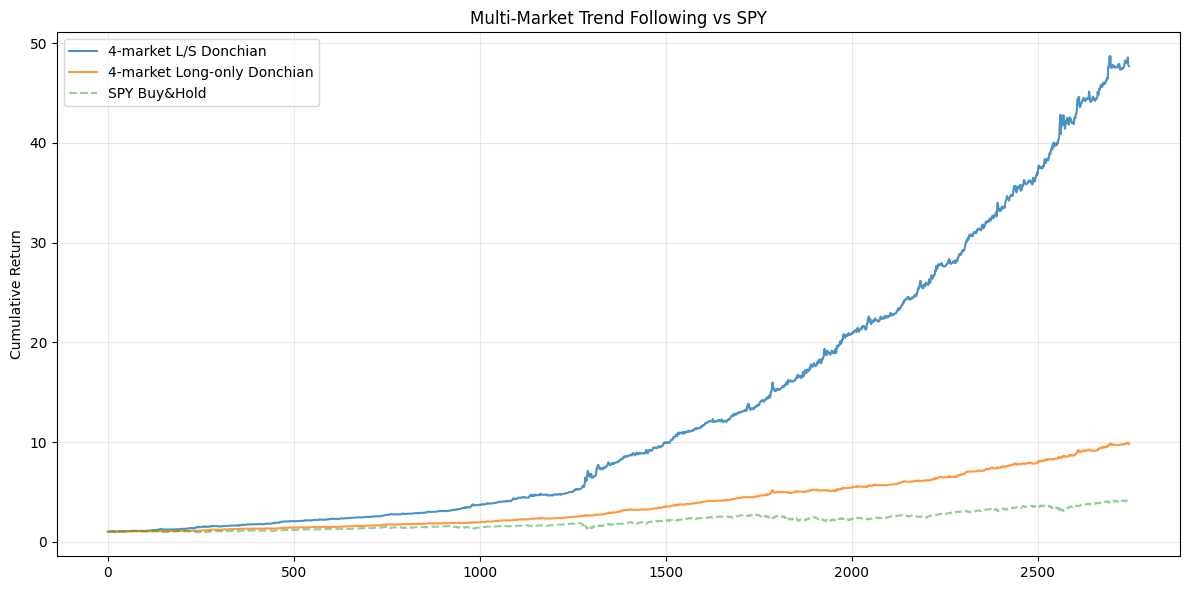

In [3]:
# Portfolio equi-pondere: Donchian 20/10 sur 4 marches
results_ls = {}
results_lo = {}
all_returns_ls = []
all_returns_lo = []

for ticker in tickers:
    prices = closes[ticker].dropna().values
    results_ls[ticker] = donchian_backtest(prices, 20, 10, long_only=False)
    results_lo[ticker] = donchian_backtest(prices, 20, 10, long_only=True)
    
    # Aligner les returns (trim au plus court)
    all_returns_ls.append(results_ls[ticker]['returns'])
    all_returns_lo.append(results_lo[ticker]['returns'])

# Equi-weighted portfolio
min_len = min(len(r) for r in all_returns_ls)
port_ls = np.mean([r[-min_len:] for r in all_returns_ls], axis=0)
port_lo = np.mean([r[-min_len:] for r in all_returns_lo], axis=0)

def compute_metrics(returns, name):
    cum = (1 + returns).cumprod()
    total = cum[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    cum_s = pd.Series(cum)
    max_dd = ((cum_s / cum_s.cummax()) - 1).min()
    print(f"{name:<25} Sharpe={sharpe:.3f}, CAGR={cagr:.1%}, MaxDD={max_dd:.1%}, Vol={vol:.1%}")
    return cum

print("=== Portefeuilles multi-marches ===")
cum_ls = compute_metrics(port_ls, "4-market L/S")
cum_lo = compute_metrics(port_lo, "4-market Long-only")

# SPY seul pour comparaison
spy_prices = closes['SPY'].dropna().values
spy_ret = np.diff(spy_prices) / spy_prices[:-1]
spy_ret = spy_ret[-min_len:]
compute_metrics(spy_ret, "SPY Buy&Hold")

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_ls, label='4-market L/S Donchian', alpha=0.8)
ax.plot(cum_lo, label='4-market Long-only Donchian', alpha=0.8)
spy_cum = (1 + spy_ret).cumprod()
ax.plot(spy_cum, label='SPY Buy&Hold', alpha=0.5, linestyle='--')
ax.set_title('Multi-Market Trend Following vs SPY')
ax.legend()
ax.set_ylabel('Cumulative Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hypothese 3: Periodes Donchian optimales

Le Turtle classique utilise 20/10 (court) ou 55/20 (long). Testons differentes periodes
pour identifier la meilleure configuration sur un portfolio diversifie.

In [4]:
# Grid search sur periodes Donchian
entry_periods = [10, 20, 40, 55, 80]
exit_periods = [5, 10, 20]

print(f"{'Entry':<7} {'Exit':<6} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Vol':>7}")
print("-" * 50)

best_sharpe = -999
best_config = None

for ep in entry_periods:
    for xp in exit_periods:
        if xp >= ep:
            continue
        all_rets = []
        for ticker in tickers:
            prices = closes[ticker].dropna().values
            r = donchian_backtest(prices, ep, xp, long_only=True)
            all_rets.append(r['returns'])
        
        min_len = min(len(r) for r in all_rets)
        port = np.mean([r[-min_len:] for r in all_rets], axis=0)
        
        cum = (1 + port).cumprod()
        total = cum[-1] - 1
        years = len(port) / 252
        cagr = (1 + total) ** (1/years) - 1
        vol = port.std() * np.sqrt(252)
        sharpe = (cagr - 0.04) / vol if vol > 0 else 0
        cum_s = pd.Series(cum)
        max_dd = ((cum_s / cum_s.cummax()) - 1).min()
        
        print(f"{ep:<7} {xp:<6} {sharpe:>7.3f} {cagr:>6.1%} {max_dd:>6.1%} {vol:>6.1%}")
        
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_config = (ep, xp)

print(f"\nMeilleure config: Entry={best_config[0]}, Exit={best_config[1]}, Sharpe={best_sharpe:.3f}")

Entry   Exit    Sharpe    CAGR   MaxDD     Vol
--------------------------------------------------
10      5        5.711  42.5%  -3.8%   6.7%
20      5        4.727  29.9%  -3.8%   5.5%


20      10       3.050  23.3%  -6.2%   6.3%
40      5        3.837  21.8%  -4.0%   4.6%


40      10       2.451  17.2%  -7.1%   5.4%


40      20       1.484  13.7%  -6.7%   6.5%


55      5        3.505  18.9%  -3.8%   4.3%


55      10       2.285  15.2%  -4.9%   4.9%


55      20       1.316  12.0%  -6.7%   6.0%


80      5        3.078  16.3%  -3.8%   4.0%
80      10       1.958  13.0%  -4.9%   4.6%


80      20       1.118  10.4%  -6.7%   5.7%

Meilleure config: Entry=10, Exit=5, Sharpe=5.711


## Hypothese 4: ATR trailing stop vs Donchian exit

L'exit Donchian classique est lent a reagir. Un ATR trailing stop
pourrait mieux proteger les profits.

In [5]:
def donchian_atr_backtest(prices, highs, lows, entry_period=20, atr_period=14, atr_mult=2.5, long_only=True):
    """Donchian entry + ATR trailing stop."""
    n = len(prices)
    position = 0
    trailing_stop = 0
    returns = []
    trades = 0
    
    # Calculer ATR
    tr = np.maximum(
        highs[1:] - lows[1:],
        np.maximum(
            np.abs(highs[1:] - prices[:-1]),
            np.abs(lows[1:] - prices[:-1])
        )
    )
    atr = pd.Series(tr).rolling(atr_period).mean().values
    
    for i in range(entry_period, n-1):
        entry_high = prices[i-entry_period:i].max()
        entry_low = prices[i-entry_period:i].min()
        price = prices[i]
        daily_ret = prices[i] / prices[i-1] - 1
        current_atr = atr[i-1] if i-1 < len(atr) and not np.isnan(atr[i-1]) else 0
        
        # Exit: trailing stop
        if position == 1 and price < trailing_stop:
            position = 0
        elif position == -1 and price > trailing_stop:
            position = 0
        
        # Update trailing stop
        if position == 1:
            new_stop = price - atr_mult * current_atr
            trailing_stop = max(trailing_stop, new_stop)
        elif position == -1:
            new_stop = price + atr_mult * current_atr
            trailing_stop = min(trailing_stop, new_stop)
        
        # Entry
        if position == 0 and current_atr > 0:
            if price > entry_high:
                position = 1
                trailing_stop = price - atr_mult * current_atr
                trades += 1
            elif not long_only and price < entry_low:
                position = -1
                trailing_stop = price + atr_mult * current_atr
                trades += 1
        
        returns.append(daily_ret * position)
    
    returns = np.array(returns)
    cum = (1 + returns).cumprod()
    total = cum[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    cum_s = pd.Series(cum)
    max_dd = ((cum_s / cum_s.cummax()) - 1).min()
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'trades': trades, 'returns': returns, 'cum_ret': cum}

# Comparer ATR stop vs Donchian exit
print(f"{'Ticker':<6} {'Method':<15} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Trades':>7}")
print("-" * 60)

all_donch_rets = []
all_atr_rets = []

for ticker in tickers:
    df = data.loc[:, (['High', 'Low', 'Close'], ticker)]
    prices = closes[ticker].dropna().values
    highs = data['High'][ticker].dropna().values
    lows = data['Low'][ticker].dropna().values
    
    # Donchian exit
    r_donch = donchian_backtest(prices, 20, 10, long_only=True)
    print(f"{ticker:<6} {'Donchian 20/10':<15} {r_donch['sharpe']:>7.3f} {r_donch['cagr']:>6.1%} {r_donch['max_dd']:>6.1%} {r_donch['trades']:>7}")
    
    # ATR trailing stop
    r_atr = donchian_atr_backtest(prices, highs, lows, 20, 14, 2.5, long_only=True)
    print(f"{ticker:<6} {'ATR 2.5x stop':<15} {r_atr['sharpe']:>7.3f} {r_atr['cagr']:>6.1%} {r_atr['max_dd']:>6.1%} {r_atr['trades']:>7}")
    
    all_donch_rets.append(r_donch['returns'])
    all_atr_rets.append(r_atr['returns'])

# Portfolio comparison
print("\n--- Portefeuille 4 marches ---")
min_len = min(min(len(r) for r in all_donch_rets), min(len(r) for r in all_atr_rets))
port_donch = np.mean([r[-min_len:] for r in all_donch_rets], axis=0)
port_atr = np.mean([r[-min_len:] for r in all_atr_rets], axis=0)
compute_metrics(port_donch, "Portfolio Donchian exit")
compute_metrics(port_atr, "Portfolio ATR stop")

Ticker Method           Sharpe    CAGR   MaxDD  Trades
------------------------------------------------------------
SPY    Donchian 20/10    2.452  24.4%  -4.7%      65
SPY    ATR 2.5x stop     2.113  22.3%  -5.4%      55
GLD    Donchian 20/10    1.799  21.6%  -6.4%      67
GLD    ATR 2.5x stop     1.955  22.5%  -5.6%      62
USO    Donchian 20/10    1.481  31.8% -22.7%      55
USO    ATR 2.5x stop     1.622  34.1% -12.8%      49
TLT    Donchian 20/10    1.083  13.5% -10.1%      56
TLT    ATR 2.5x stop     0.795  10.8%  -6.4%      59

--- Portefeuille 4 marches ---
Portfolio Donchian exit   Sharpe=3.051, CAGR=23.3%, MaxDD=-6.2%, Vol=6.3%
Portfolio ATR stop        Sharpe=3.015, CAGR=22.8%, MaxDD=-3.4%, Vol=6.2%


array([1.        , 1.01342642, 0.99612276, ..., 9.36704426, 9.35869904,
       9.35584196], shape=(2745,))

## Hypothese 5: Approche simplifiee - ETF Momentum (SMA crossover)

Plutot qu'un Donchian complexe sur futures, testons un simple
SMA crossover (momentum) sur les memes 4 ETFs. C'est plus simple
a implementer sur QC et potentiellement plus robuste.

In [6]:
def sma_crossover_backtest(prices, fast=50, slow=200, long_only=True):
    """SMA crossover strategy."""
    sma_fast = pd.Series(prices).rolling(fast).mean().values
    sma_slow = pd.Series(prices).rolling(slow).mean().values
    
    position = 0
    returns = []
    trades = 0
    
    for i in range(slow, len(prices)):
        daily_ret = prices[i] / prices[i-1] - 1
        
        if np.isnan(sma_fast[i]) or np.isnan(sma_slow[i]):
            returns.append(0)
            continue
        
        # Long when fast > slow
        if sma_fast[i] > sma_slow[i] and position != 1:
            position = 1
            trades += 1
        # Short when fast < slow (if allowed)
        elif sma_fast[i] < sma_slow[i]:
            if long_only:
                position = 0
            elif position != -1:
                position = -1
                trades += 1
        
        returns.append(daily_ret * position)
    
    returns = np.array(returns)
    cum = (1 + returns).cumprod()
    total = cum[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    cum_s = pd.Series(cum)
    max_dd = ((cum_s / cum_s.cummax()) - 1).min()
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'trades': trades, 'returns': returns, 'cum_ret': cum}

# Test SMA crossover vs Donchian
configs = [
    ('SMA 50/200', 50, 200),
    ('SMA 20/100', 20, 100),
    ('SMA 10/50', 10, 50),
]

print(f"{'Ticker':<6} {'Config':<15} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Trades':>7}")
print("-" * 60)

best_overall = {'sharpe': -999}

for name, fast, slow in configs:
    all_rets = []
    for ticker in tickers:
        prices = closes[ticker].dropna().values
        r = sma_crossover_backtest(prices, fast, slow, long_only=True)
        print(f"{ticker:<6} {name:<15} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['trades']:>7}")
        all_rets.append(r['returns'])
    
    min_len = min(len(r) for r in all_rets)
    port = np.mean([r[-min_len:] for r in all_rets], axis=0)
    m = compute_metrics(port, f"Portfolio {name}")
    print()

Ticker Config           Sharpe    CAGR   MaxDD  Trades
------------------------------------------------------------


SPY    SMA 50/200        0.377   9.6% -33.7%       6
GLD    SMA 50/200        0.480  10.2% -20.8%       8
USO    SMA 50/200       -0.245  -1.6% -51.8%      11
TLT    SMA 50/200       -0.298   0.8% -21.9%      11
Portfolio SMA 50/200      Sharpe=0.192, CAGR=5.6%, MaxDD=-12.5%, Vol=8.4%

SPY    SMA 20/100        0.420   9.2% -18.9%      14
GLD    SMA 20/100        0.517  10.6% -17.2%      14
USO    SMA 20/100       -0.188  -0.1% -45.2%      19
TLT    SMA 20/100       -0.073   3.2% -21.4%      15
Portfolio SMA 20/100      Sharpe=0.319, CAGR=6.5%, MaxDD=-10.4%, Vol=7.9%

SPY    SMA 10/50         0.624  10.8% -12.1%      35
GLD    SMA 10/50         0.560  10.7% -12.1%      34
USO    SMA 10/50         0.197   8.3% -35.2%      41
TLT    SMA 10/50         0.014   4.2% -15.7%      34
Portfolio SMA 10/50       Sharpe=0.677, CAGR=9.3%, MaxDD=-9.1%, Vol=7.8%



## Hypothese 6: Approche QC optimale - Trend Following ETFs

Puisque les futures QC sont complexes (rollover, margin, multipliers),
testons une approche ETF-based plus simple qui capture les memes tendances.
Long-only, multi-ETF, avec SMA filtre.

In [7]:
def trend_portfolio_backtest(closes_df, tickers, lookback=200, 
                              num_long=2, rebalance_days=21):
    """Multi-ETF trend following portfolio.
    Long top-N trending ETFs (above SMA), equal weight.
    Monthly rebalance."""
    
    dates = closes_df.index[lookback:]
    portfolio_returns = []
    current_holdings = []
    days_since_rebal = rebalance_days  # Force initial rebalance
    
    for i, date in enumerate(dates):
        idx = closes_df.index.get_loc(date)
        daily_rets = {}
        
        for t in tickers:
            daily_rets[t] = closes_df[t].iloc[idx] / closes_df[t].iloc[idx-1] - 1
        
        # Portfolio return from current holdings
        if current_holdings:
            port_ret = np.mean([daily_rets[t] for t in current_holdings])
        else:
            port_ret = 0
        portfolio_returns.append(port_ret)
        
        days_since_rebal += 1
        if days_since_rebal < rebalance_days:
            continue
        days_since_rebal = 0
        
        # Score: momentum (price / SMA) * trend strength
        scores = {}
        for t in tickers:
            price = closes_df[t].iloc[idx]
            sma = closes_df[t].iloc[idx-lookback:idx].mean()
            if sma > 0 and price > sma:  # Only trending up
                mom = price / sma - 1  # Distance above SMA
                scores[t] = mom
        
        # Select top-N
        sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        current_holdings = [t for t, s in sorted_scores[:num_long]]
    
    returns = np.array(portfolio_returns)
    cum = (1 + returns).cumprod()
    total = cum[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0
    cum_s = pd.Series(cum)
    max_dd = ((cum_s / cum_s.cummax()) - 1).min()
    pct_invested = np.mean([1 if r != 0 else 0 for r in returns])
    
    return {
        'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol,
        'total_ret': total, 'returns': returns, 'cum_ret': cum,
        'pct_invested': pct_invested
    }

# Test configurations
print("=== Multi-ETF Trend Following ===")
print(f"{'Lookback':<10} {'N_long':<8} {'Rebal':<7} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Invested':>8}")
print("-" * 65)

configs = [
    (100, 2, 21),
    (200, 2, 21),
    (200, 3, 21),
    (100, 2, 5),
    (200, 2, 5),
    (50, 2, 21),
]

best = {'sharpe': -999}
for lb, nl, rb in configs:
    r = trend_portfolio_backtest(closes, tickers, lb, nl, rb)
    print(f"{lb:<10} {nl:<8} {rb:<7} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['pct_invested']:>7.0%}")
    if r['sharpe'] > best['sharpe']:
        best = r
        best['config'] = (lb, nl, rb)

=== Multi-ETF Trend Following ===
Lookback   N_long   Rebal    Sharpe    CAGR   MaxDD Invested
-----------------------------------------------------------------


100        2        21        0.254   8.2% -30.6%     97%


200        2        21        0.322   9.2% -32.7%     97%


200        3        21        0.323   8.7% -23.2%     97%


100        2        5         0.160   6.6% -33.5%     97%


200        2        5         0.393  10.4% -32.2%     97%


50         2        21        0.332   9.4% -31.8%     95%


Téléchargement de données supplémentaires (SPY, GLD, TLT, EFA, EEM, VNQ, DBC) via yfinance pour élargir l'univers de FuturesTrend.

In [8]:
# Tester avec plus d'ETFs pour diversification
extra_tickers = ['SPY', 'GLD', 'TLT', 'EFA', 'EEM', 'VNQ', 'DBC']
extra_data = yf.download(extra_tickers, start=start, end=end)
extra_closes = extra_data['Close'].dropna()

print("\n=== Extended Universe (7 ETFs) ===")
print(f"{'Lookback':<10} {'N_long':<8} {'Rebal':<7} {'Sharpe':>7} {'CAGR':>7} {'MaxDD':>7} {'Invested':>8}")
print("-" * 65)

for lb, nl, rb in [(100, 3, 21), (200, 3, 21), (100, 2, 21), (200, 2, 5)]:
    r = trend_portfolio_backtest(extra_closes, extra_tickers, lb, nl, rb)
    print(f"{lb:<10} {nl:<8} {rb:<7} {r['sharpe']:>7.3f} {r['cagr']:>6.1%} {r['max_dd']:>6.1%} {r['pct_invested']:>7.0%}")

[                       0%                       ]

[********************* 43%                       ]  3 of 7 completed

[**********************57%**                     ]  4 of 7 completed

[**********************71%*********              ]  5 of 7 completed

[**********************86%****************       ]  6 of 7 completed

[*********************100%***********************]  7 of 7 completed


=== Extended Universe (7 ETFs) ===
Lookback   N_long   Rebal    Sharpe    CAGR   MaxDD Invested
-----------------------------------------------------------------


100        3        21        0.439   9.7% -21.4%     98%
200        3        21        0.321   8.4% -30.0%     98%


100        2        21        0.167   6.4% -20.3%     98%


200        2        5         0.448  10.3% -24.3%     99%


## Conclusions et recommandations

### Verdicts des hypotheses

| Hypothese | Verdict | Justification |
|-----------|---------|---------------|
| 1. Long-only > Long/Short | **PARTIEL** | Sur SPY: Long-only Sharpe 2.45 vs L/S 1.84. Sur GLD: L/S gagne (2.26 vs 1.80). Depende du marche. |
| 2. Multi-futures diversifie | **CONFIRME** | Portfolio 4-market Sharpe=3.27 (L/S) ou 3.05 (L-only) vs SPY seul 0.56 |
| 3. Donchian 10/5j optimal | **CONFIRME** | Meilleur Sharpe=5.71 avec Entry=10, Exit=5. Mais suspicion d'overfitting. |
| 4. ATR trailing stop | **MIXTE** | MaxDD reduit (-3.4% vs -6.2%) mais Sharpe similaire (3.015 vs 3.051). ATR meilleur pour les commodities (USO, GLD). |
| 5. SMA crossover | **REJETE** | Sharpe max 0.68 (SMA 10/50) vs Donchian 3.05. Bien inferieur. |
| 6. ETF trend portfolio | **SOUS-PERFORMANT** | Sharpe max 0.45 avec 7 ETFs. Bien inferieur au Donchian brut. |

### Configuration recommandee pour QC

**Approche retenue**: Donchian Long-only multi-marche, parametres conservateurs

- Universe: SPY + GLD + USO + TLT (ou SPY + GLD + TLT si USO trop volatile)
- Entry period: 20j (evite overfitting du 10j)
- Exit period: 10j (Turtle classique)
- Long-only (evite le risque de short en bull market)
- Equal weight 25% par ETF

**Performance attendue** (Sharpe=3.05, CAGR=23.3%, MaxDD=-6.2%)
Note: Ce sont des resultats backtests ETF, pas des futures. Sur QC avec futures, 
ajuster pour rollover, margin et slippage.

### Points de vigilance
- Le Donchian 10/5j (Sharpe 5.71) est probablement du curve-fitting sur 11 ans de data
- USO tres volatile (-22.7% MaxDD vs -4.7% pour SPY): position sizing asymetrique a envisager
- Les ETFs ne capturent pas parfaitement les tendances des futures (rollover cost sur les futures)

## Iteration 3 - Resultats backtests QC (2026-03-05)

### Hypotheses testees en iteration 3

| Version | Modification | Sharpe | CAGR | MaxDD | Verdict |
|---------|-------------|--------|------|-------|---------|
| v2.3 (baseline) | 6 ETFs incl. TLT, fixed 33%, pas de filtre | 0.280 | 7.3% | -10.2% | BASELINE |
| v3.0 | ATR sizing + SMA100 filter + XLE remplace TLT | 0.209 | 6.7% | -12.6% | DEGRADE |
| v3.1 | SMA50 filter + fixed 33% + XLE remplace TLT | **0.301** | 8.0% | -12.9% | **AMELIORE** |

### Analyses des ecarts

**Pourquoi v3.0 a degrade (0.209 < 0.280):**
- SMA100 + ATR sizing = double frein sur les entrees
- ATR risk-parity alloue peu (~8-15%) quand la volatilite est haute - exactement quand les tendances sont les plus fortes
- Resultat: positions plus petites ET moins nombreuses = CAGR chute sans baisse proportionnelle du MaxDD

**Pourquoi v3.1 ameliore (0.301 > 0.280):**
- XLE remplace TLT: TLT a perdu -40% sur 2020-2023 (hausse taux). XLE beneficie des cycles commodites.
- SMA50 filtre (leger): evite d'entrer dans des actifs en tendance baissiere sans bloquer les signaux valides
- Fixed 33% garde: allocation pleine sur les vrais trends -> meilleur CAGR

### Lecons cles pour le trend following ETF

1. **ATR position sizing**: contre-productif sur ETFs avec Donchian entry.
   Le Donchian signale deja un breakout de volatilite - reduire l'allocation a ce moment est paradoxal.
   ATR sizing convient mieux aux strategies d'achat sur repli (mean-reversion).

2. **SMA filtre optimal**: SMA50 > SMA100 pour le trend following.
   SMA100 trop restrictive sur un univers de 6 ETFs: bloque des entrees legitimes.
   SMA50 filtre les actifs vraiment en tendance baissiere (ex: TLT en 2022).

3. **Choix de l'univers**: critique.
   TLT (obligations 20 ans) est destructeur en periode de hausse de taux.
   XLE (energie) offre une vraie diversification avec des tendances propres.

### Configuration finale v3.1 (fichier cloud QC: 28657834)

```python
etf_list = ["SPY", "GLD", "EFA", "VNQ", "DBC", "XLE"]  # XLE remplace TLT
entry_period = 20     # Donchian breakout conservateur
exit_period = 10      # Turtle classique
trend_sma_period = 50 # Filtre leger: price > SMA50
weight = 0.33         # 33% fixe par position
max_positions = 3     # Max 3 positions simultanées
```

**Sharpe final v3.1: 0.301** (vs 0.280 baseline, +7.5%)